# **Tutorial: PV + BESS Sizing Optimizer for Prosumers**

This tutorial demonstrates how to use the `ProsumerOptimizer` class to find the **Pareto-optimal sizing** of a photovoltaic (PV) system and battery energy storage (BESS) for a prosumer.

**Steps:**
1. Load demand data and meteorological data
2. Configure and run the optimizer (two objective modes)
3. Select the best-compromise solution
4. Analyse energy, economic, and environmental performance

---
## **Step 0 - Imports**

In [1]:
import os, sys
from pathlib import Path

# Set working directory to project root (one level up from tutorials/)
os.chdir(Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd())
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.kernel.run import fetch_meteo
from src.optimizer.prosumer_optimizer import ProsumerOptimizer

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## **Step 1 - Load Demand Data**

We select **user1** — a medium-size commercial prosumer (~180 MWh/year).

Prosumer:        user1
Time steps:      35040  (365 days)
Peak demand:     58.0 kW
Annual demand:   180.8 MWh


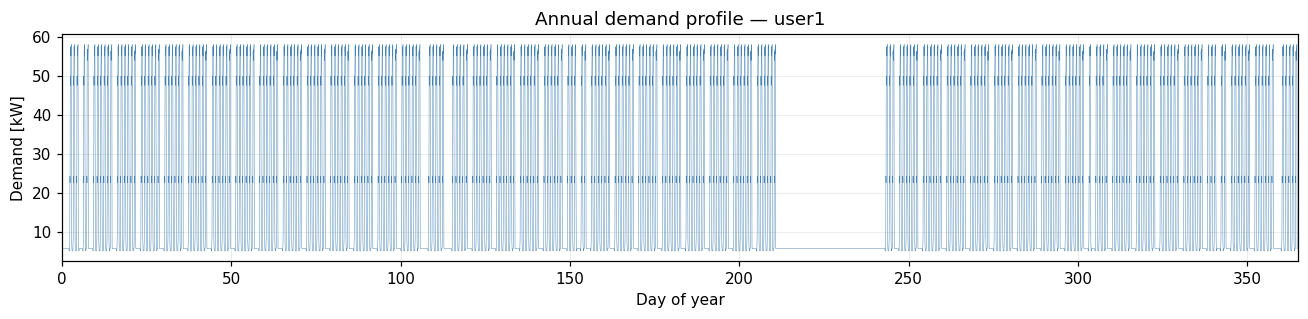

In [2]:
demand_path = Path("src/example_model/Rec1/Input/demand_qc_kw_el.csv")
demand_df = pd.read_csv(demand_path, sep=';')

prosumer_id = 'user1'
demand = demand_df[prosumer_id].values  # kW, quarter-hourly

print(f"Prosumer:        {prosumer_id}")
print(f"Time steps:      {len(demand)}  ({len(demand)*0.25/24:.0f} days)")
print(f"Peak demand:     {demand.max():.1f} kW")
print(f"Annual demand:   {demand.sum() * 0.25 / 1000:.1f} MWh")

fig, ax = plt.subplots(figsize=(12, 3))
days = np.arange(len(demand)) * 0.25 / 24
ax.plot(days, demand, linewidth=0.3, color='steelblue')
ax.set(xlabel='Day of year', ylabel='Demand [kW]', xlim=(0, 365))
ax.set_title(f'Annual demand profile — {prosumer_id}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## **Step 2 - Fetch Meteorological Data**

Irradiation and temperature from **PVGIS** for Rome, Italy. Data is cached locally after first download.

In [3]:
lat, lon = 41.9028, 12.4964
tilt, azimuth = 30, 0
time_step = 0.25

cache_dir = Path("src/example_model/Rec1/.pvgis_cache")
I_beam, I_skydiff, I_grounddiff, t_amb, wind_speed, theta = fetch_meteo(
    lat=lat, lon=lon, tilt=tilt, azimuth=azimuth,
    time_step_str='15min', time_step_hours=time_step, cache_dir=cache_dir)

meteo = dict(I_beam=I_beam, I_skydiff=I_skydiff, I_grounddiff=I_grounddiff,
             t_amb=t_amb, wind_speed=wind_speed, theta=theta)

print(f"Meteo: {len(I_beam)} timesteps")
print(f"Annual POA irradiation: {(I_beam.sum()+I_skydiff.sum()+I_grounddiff.sum())/1000:.0f} kWh/m2")

Meteo: 35040 timesteps
Annual POA irradiation: 4394 kWh/m2


---
## **Step 3 - Configure the Optimizer**

| Parameter | Value | Description |
|-----------|-------|-------------|
| `space_max` | 300 m2 | Available roof area |
| `utilization_factor` | 0.6 | Usable fraction |
| `specific_budget` | 2000 EUR/kWp | Budget cap (PV+BESS) |
| `n_series_pv` | 10 | Modules per string (~4 kWp) |
| `min_self_cons_ratio` | 0.05 | Min 5% self-consumption |

In [4]:
pv_economics = {
    'cap_cost': 1500, 'opex_cost': 40,
    'inverter_cost': 350, 'inverter_year': 10,
    'inc_rate': 0.5, 'inc_cap': 96000, 'inc_duration': 10,
}
bess_economics = {
    'cap_cost': 720, 'opex_cost': 20,
    'inc_rate': 0.5, 'inc_cap': 96000, 'inc_duration': 10,
}
prosumer_economics = {
    'tax_rate': 0.2, 'int_rate': 0.03,
    'price_buy': 130, 'price_sold': 104,
    'decay': 0.02, 'prod_degradation': 0.005,
}

common_kwargs = dict(
    demand=demand, meteo=meteo, time_step=time_step, tilt=tilt,
    n_series_pv=10, pv_economics=pv_economics,
    n_series_bess=1, bess_economics=bess_economics,
    space_max=300.0, utilization_factor=0.6, specific_budget=2000.0,
    min_self_cons_ratio=0.05, max_prod_dem_ratio=2.0,
    prosumer_economics=prosumer_economics, time_horizon=20,
    pop_size=80, n_gen=40, seed=42,
)

---
## **Step 4 - Run Optimization**

### Mode A: Self-Consumption
Maximizes absolute self-consumption [MWh/y] + NPV [EUR]. Best for **investment decisions** on a specific site.

In [5]:
opt_sc = ProsumerOptimizer(**common_kwargs, objective_mode='self_consumption')
opt_sc.summary()
results_sc = opt_sc.optimize()

  ProsumerOptimizer — self_consumption
  Time step:           0.25 h  (35040 steps)
  Annual demand:       180.83 MWh
  PV module:           400 W, 2.07 m²
  PV string:           10 modules → 4.00 kWp
  Net surface:         180.0 m²
  Max PV strings:      8  (32.0 kWp)
  BESS module:         2.560 kWh
  Max BESS parallel:   34  (87.0 kWh)
  Budget max:          64,051 €
  NSGA-II:             pop=80, gen=40
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       69 |      2 |  0.000000E+00 |  7.262737E+03 |             - |             -
     2 |      109 |      2 |  0.000000E+00 |  3.663541E+02 |  0.000000E+00 |             f
     3 |      149 |      2 |  0.000000E+00 |  0.0005264899 |  0.000000E+00 |             f
     4 |      189 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      229 |      3 |  0.000000E+00 |  0.000000E+00 |  0.8238185137 |         ideal
     6 |      269 |      4 |  0.000000E+00 

In [6]:
results_sc.drop_duplicates(subset=['n_parallel_pv','n_parallel_bess'])

,n_parallel_pv,n_parallel_bess,cap_pv_kW,cap_bess_kWh,capex_EUR,self_cons_MWh,NPV_EUR
0,8,8,32.03,21.09,63222.0,28.3421,13534.0
9,8,7,32.03,19.56,62123.0,28.2525,16352.0
21,8,6,32.03,16.30,59774.0,28.1640,19173.0
36,8,5,32.03,15.27,59032.0,28.0724,21988.0
44,8,4,32.03,12.39,56959.0,27.9777,24796.0
51,8,3,32.03,9.14,54621.0,27.8789,27595.0
58,8,2,32.03,6.74,52894.0,27.7797,30394.0
62,8,1,32.03,2.72,49996.0,27.6766,33185.0
70,8,0,32.03,1.01,48762.0,27.5342,35896.0


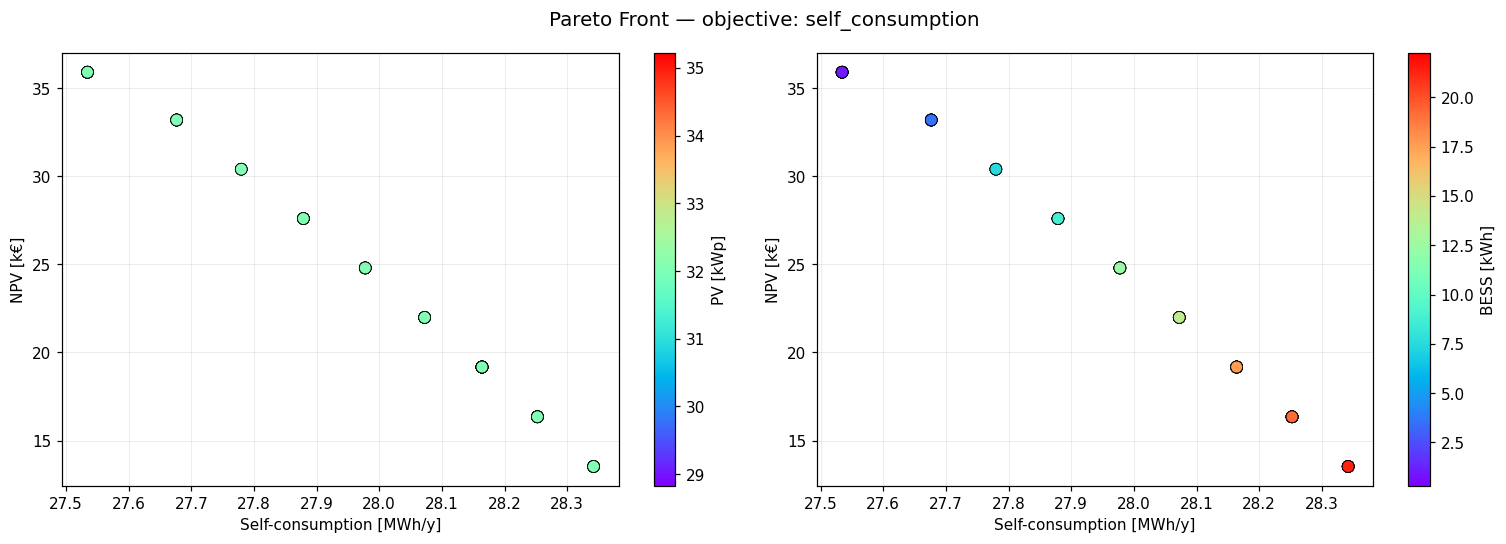

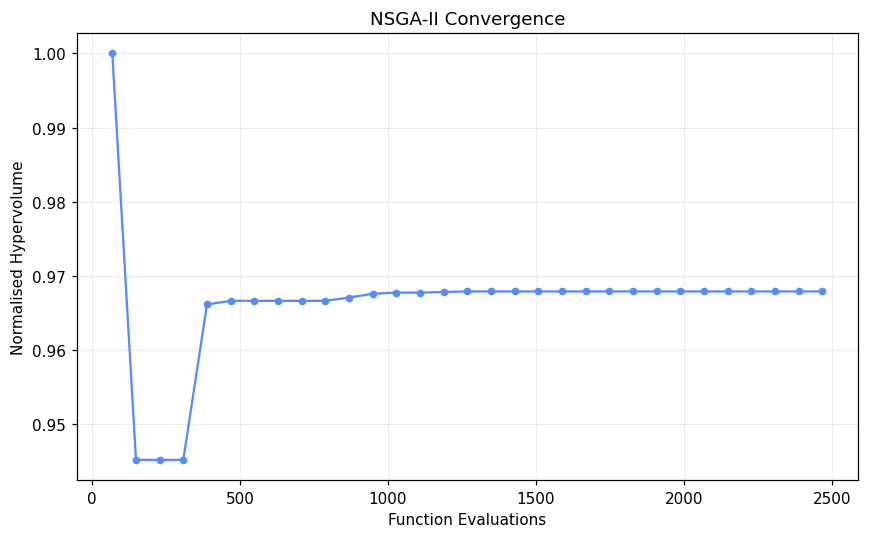

In [7]:
opt_sc.plot_pareto()
plt.show()

opt_sc.plot_convergence()
plt.show()

### Mode B: Self-Sufficiency
Maximizes self-sufficiency rate [0-1] + NPV [EUR]. Best for **parametric studies** or when a specific coverage target is set.

In [8]:
opt_ss = ProsumerOptimizer(**common_kwargs, objective_mode='self_sufficiency')
results_ss = opt_ss.optimize()

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       69 |      2 |  0.000000E+00 |  7.262737E+03 |             - |             -
     2 |      109 |      2 |  0.000000E+00 |  3.663541E+02 |  0.000000E+00 |             f
     3 |      149 |      2 |  0.000000E+00 |  0.0005264899 |  0.000000E+00 |             f
     4 |      189 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      229 |      3 |  0.000000E+00 |  0.000000E+00 |  0.8237628443 |         ideal
     6 |      269 |      4 |  0.000000E+00 |  0.000000E+00 |  0.0419561150 |             f
     7 |      309 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     8 |      349 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      389 |      4 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
    10 |      429 |      6 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

In [9]:
results_ss.drop_duplicates(subset=['n_parallel_pv','n_parallel_bess'])

,n_parallel_pv,n_parallel_bess,cap_pv_kW,cap_bess_kWh,capex_EUR,self_sufficiency,NPV_EUR
0,8,8,32.03,21.20,63300.0,0.1563,13534.0
9,8,7,32.03,20.08,62497.0,0.1559,16352.0
22,8,6,32.03,16.96,60249.0,0.1554,19173.0
28,8,5,32.03,14.41,58410.0,0.1550,21988.0
36,8,4,32.03,10.26,55425.0,0.1545,24796.0
45,8,3,32.03,10.22,55395.0,0.1540,27595.0
54,8,2,32.03,6.04,52386.0,0.1535,30394.0
63,8,1,32.03,4.39,51199.0,0.1530,33185.0
72,8,0,32.03,2.28,49677.0,0.1523,35896.0


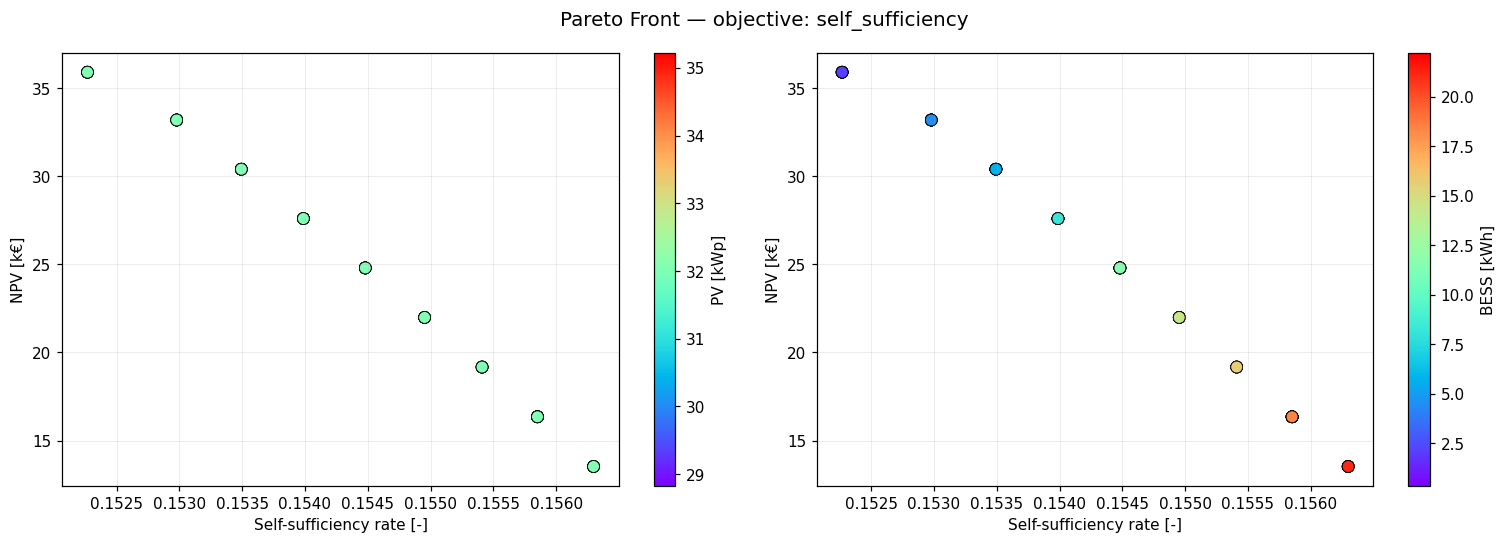

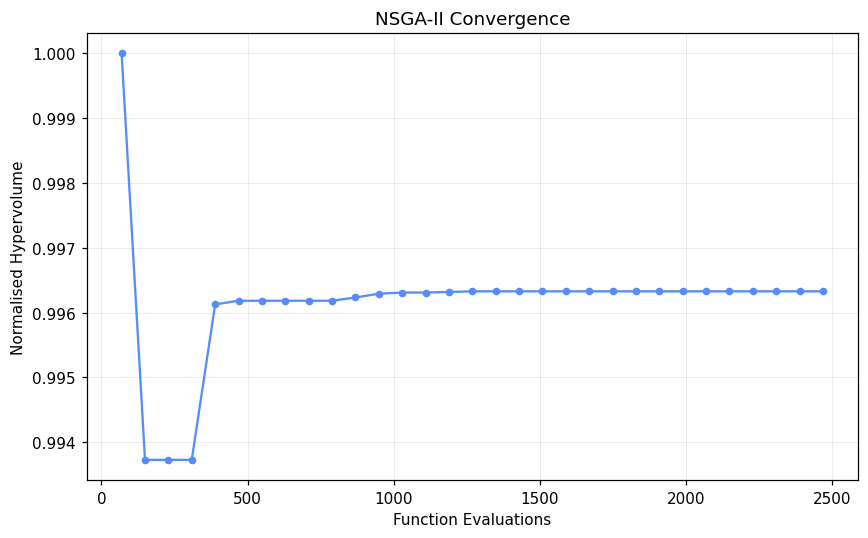

In [10]:
opt_ss.plot_pareto()
plt.show()

opt_ss.plot_convergence()
plt.show()

---
## **Step 5 - Select Optimal Solution**

We select a **best-compromise** solution from the Pareto front using the min-max normalisation (TOPSIS-like): the solution closest to the ideal point in normalised objective space.

In [11]:
# Select best-compromise from Mode A
F = opt_sc.pareto_F
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
distances = np.sqrt((F_norm ** 2).sum(axis=1))
best_idx = np.argmin(distances)

best_X = opt_sc.pareto_X[best_idx]
n_pv_opt, n_bess_opt = int(best_X[0]), int(best_X[1])

cap_pv_opt = n_pv_opt * opt_sc.n_series_pv * opt_sc.cap_module_pv
cap_bess_opt = n_bess_opt * opt_sc.n_series_bess * opt_sc.cap_module_bess

print(f"Best-compromise solution:")
print(f"  PV:   {n_pv_opt} strings x {opt_sc.n_series_pv} modules = {cap_pv_opt:.1f} kWp")
print(f"  BESS: {n_bess_opt} parallel x {opt_sc.cap_module_bess:.2f} kWh = {cap_bess_opt:.1f} kWh")
print(f"  Self-consumption: {opt_sc.pareto_F[best_idx, 0]:.2f} MWh/y")
print(f"  NPV (incremental): {opt_sc.pareto_F[best_idx, 1]:,.0f} EUR")

Best-compromise solution:
  PV:   8 strings x 10 modules = 32.0 kWp
  BESS: 4 parallel x 2.56 kWh = 10.2 kWh
  Self-consumption: 27.98 MWh/y
  NPV (incremental): 24,796 EUR


In [12]:
# Select best-compromise from Mode B
F_b = opt_ss.pareto_F
F_b_norm = (F_b - F_b.min(axis=0)) / (F_b.max(axis=0) - F_b.min(axis=0) + 1e-12)
dist_b = np.sqrt((F_b_norm ** 2).sum(axis=1))
best_idx_b = np.argmin(dist_b)

best_X_b = opt_ss.pareto_X[best_idx_b]
n_pv_ss, n_bess_ss = int(best_X_b[0]), int(best_X_b[1])

cap_pv_ss = n_pv_ss * opt_ss.n_series_pv * opt_ss.cap_module_pv
cap_bess_ss = n_bess_ss * opt_ss.n_series_bess * opt_ss.cap_module_bess

print(f"Best-compromise solution (Mode B - Self-Sufficiency):")
print(f"  PV:   {n_pv_ss} strings x {opt_ss.n_series_pv} modules = {cap_pv_ss:.1f} kWp")
print(f"  BESS: {n_bess_ss} parallel x {opt_ss.cap_module_bess:.2f} kWh = {cap_bess_ss:.1f} kWh")
print(f"  Self-sufficiency: {opt_ss.pareto_F[best_idx_b, 0]:.2%}")
print(f"  NPV (incremental): {opt_ss.pareto_F[best_idx_b, 1]:,.0f} EUR")

Best-compromise solution (Mode B - Self-Sufficiency):
  PV:   8 strings x 10 modules = 32.0 kWp
  BESS: 4 parallel x 2.56 kWh = 10.2 kWh
  Self-sufficiency: 15.45%
  NPV (incremental): 24,796 EUR


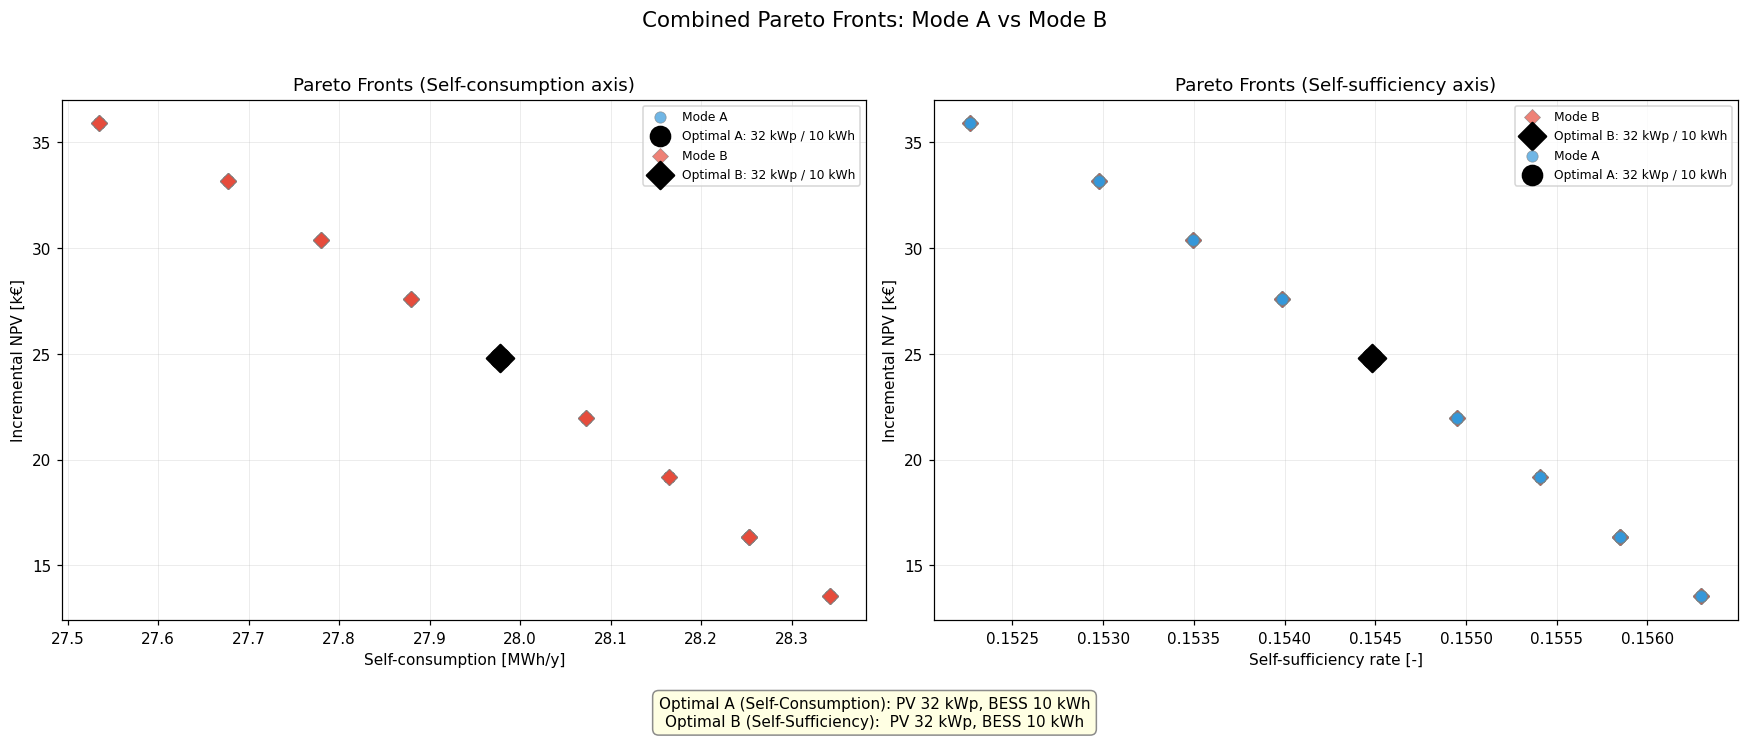

In [13]:
# --- Combined Pareto front: Mode A vs Mode B ---
F_a = opt_sc.pareto_F   # columns: self_cons_MWh, NPV_EUR
F_b = opt_ss.pareto_F   # columns: self_sufficiency, NPV_EUR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: Self-consumption axis (Mode A native, Mode B mapped) ---
# Mode A: self-consumption [MWh/y] vs NPV
ax1.scatter(F_a[:, 0], F_a[:, 1] / 1000, s=55, marker='o',
            facecolors='#3498db', edgecolors='grey', linewidths=0.5,
            alpha=0.7, label='Mode A', zorder=2)
ax1.scatter(F_a[best_idx, 0], F_a[best_idx, 1] / 1000, s=160, marker='o',
            facecolors='black', edgecolors='black', linewidths=1.5,
            zorder=4, label=f'Optimal A: {cap_pv_opt:.0f} kWp / {cap_bess_opt:.0f} kWh')

# Mode B on same axis: compute self-consumption for each B solution
sc_mwh_b = []
for i in range(len(opt_ss.pareto_X)):
    n_pv_i = int(opt_ss.pareto_X[i, 0])
    n_bess_i = int(opt_ss.pareto_X[i, 1])
    prod_i = n_pv_i * opt_ss._prod_per_string
    sc_no_bess = np.minimum(prod_i, opt_ss.demand)
    if n_bess_i > 0:
        from src.rec_sim.Controller import Controller as _Ctrl
        bess_i = opt_ss._make_bess(n_bess_i)
        ctrl_i = _Ctrl(bess=[bess_i])
        stored_i, *_ = ctrl_i.energy_performance(
            production=prod_i, demand=opt_ss.demand, time=opt_ss.time_step)
        sc_mwh_b.append(float(np.sum(sc_no_bess + stored_i)) * opt_ss.time_step / 1000)
    else:
        sc_mwh_b.append(float(np.sum(sc_no_bess)) * opt_ss.time_step / 1000)
sc_mwh_b = np.array(sc_mwh_b)

ax1.scatter(sc_mwh_b, F_b[:, 1] / 1000, s=55, marker='D',
            facecolors='#e74c3c', edgecolors='grey', linewidths=0.5,
            alpha=0.7, label='Mode B', zorder=2)
ax1.scatter(sc_mwh_b[best_idx_b], F_b[best_idx_b, 1] / 1000, s=160, marker='D',
            facecolors='black', edgecolors='black', linewidths=1.5,
            zorder=4, label=f'Optimal B: {cap_pv_ss:.0f} kWp / {cap_bess_ss:.0f} kWh')

ax1.set_xlabel('Self-consumption [MWh/y]')
ax1.set_ylabel('Incremental NPV [k\u20ac]')
ax1.set_title('Pareto Fronts (Self-consumption axis)')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# --- Right panel: Self-sufficiency axis (Mode B native, Mode A mapped) ---
# Mode B: self-sufficiency vs NPV
ax2.scatter(F_b[:, 0], F_b[:, 1] / 1000, s=55, marker='D',
            facecolors='#e74c3c', edgecolors='grey', linewidths=0.5,
            alpha=0.7, label='Mode B', zorder=2)
ax2.scatter(F_b[best_idx_b, 0], F_b[best_idx_b, 1] / 1000, s=160, marker='D',
            facecolors='black', edgecolors='black', linewidths=1.5,
            zorder=4, label=f'Optimal B: {cap_pv_ss:.0f} kWp / {cap_bess_ss:.0f} kWh')

# Mode A on self-sufficiency axis: compute self-sufficiency for each A solution
ss_rate_a = []
dem_mwh = opt_sc._dem_mwh
for i in range(len(opt_sc.pareto_X)):
    n_pv_i = int(opt_sc.pareto_X[i, 0])
    n_bess_i = int(opt_sc.pareto_X[i, 1])
    prod_i = n_pv_i * opt_sc._prod_per_string
    unmet_no_bess = np.maximum(0.0, opt_sc.demand - prod_i)
    if n_bess_i > 0:
        bess_i = opt_sc._make_bess(n_bess_i)
        ctrl_i = _Ctrl(bess=[bess_i])
        _, _, _, _, deficit_i, _ = ctrl_i.energy_performance(
            production=prod_i, demand=opt_sc.demand, time=opt_sc.time_step)
        purchased_i = float(np.sum(deficit_i)) * opt_sc.time_step / 1000
    else:
        purchased_i = float(np.sum(unmet_no_bess)) * opt_sc.time_step / 1000
    ss_rate_a.append((dem_mwh - purchased_i) / dem_mwh if dem_mwh > 0 else 0)
ss_rate_a = np.array(ss_rate_a)

ax2.scatter(ss_rate_a, F_a[:, 1] / 1000, s=55, marker='o',
            facecolors='#3498db', edgecolors='grey', linewidths=0.5,
            alpha=0.7, label='Mode A', zorder=2)
ax2.scatter(ss_rate_a[best_idx], F_a[best_idx, 1] / 1000, s=160, marker='o',
            facecolors='black', edgecolors='black', linewidths=1.5,
            zorder=4, label=f'Optimal A: {cap_pv_opt:.0f} kWp / {cap_bess_opt:.0f} kWh')

ax2.set_xlabel('Self-sufficiency rate [-]')
ax2.set_ylabel('Incremental NPV [k\u20ac]')
ax2.set_title('Pareto Fronts (Self-sufficiency axis)')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)

# --- Annotation box ---
note = (f"Optimal A (Self-Consumption): PV {cap_pv_opt:.0f} kWp, BESS {cap_bess_opt:.0f} kWh\n"
        f"Optimal B (Self-Sufficiency):  PV {cap_pv_ss:.0f} kWp, BESS {cap_bess_ss:.0f} kWh")
fig.text(0.5, -0.02, note, ha='center', va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey', alpha=0.9))

fig.suptitle('Combined Pareto Fronts: Mode A vs Mode B', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## **Step 6 - Energy Performance**

Detailed simulation of the best-compromise configurations from both modes.

In [14]:
# --- Mode A simulation ---
sim_a = opt_sc.simulate_solution(n_pv_opt, n_bess_opt)
en_a = sim_a['energy']
ann_a = sim_a['annual']

# --- Mode B simulation ---
sim_b = opt_ss.simulate_solution(n_pv_ss, n_bess_ss)
en_b = sim_b['energy']
ann_b = sim_b['annual']

for tag, ann_x in [('Mode A (Self-Consumption)', ann_a), ('Mode B (Self-Sufficiency)', ann_b)]:
    print(f"--- {tag} — Annual Energy Balance ---")
    print(f"  Production:       {ann_x['prod_MWh']:8.1f} MWh")
    print(f"  Demand:           {ann_x['dem_MWh']:8.1f} MWh")
    print(f"  Self-consumption: {ann_x['self_cons_MWh']:8.1f} MWh")
    print(f"  Surplus (sold):   {ann_x['surplus_MWh']:8.1f} MWh")
    print(f"  Purchased:        {ann_x['purchased_MWh']:8.1f} MWh")
    print(f"  Self-sufficiency: {ann_x['self_suff_rate']:8.1%}")
    print(f"  Self-cons. rate:  {ann_x['self_cons_rate']:8.1%}")
    print()

--- Mode A (Self-Consumption) — Annual Energy Balance ---
  Production:           31.8 MWh
  Demand:              180.8 MWh
  Self-consumption:     28.0 MWh
  Surplus (sold):        3.8 MWh
  Purchased:           152.9 MWh
  Self-sufficiency:    15.4%
  Self-cons. rate:     87.9%

--- Mode B (Self-Sufficiency) — Annual Energy Balance ---
  Production:           31.8 MWh
  Demand:              180.8 MWh
  Self-consumption:     28.0 MWh
  Surplus (sold):        3.8 MWh
  Purchased:           152.9 MWh
  Self-sufficiency:    15.4%
  Self-cons. rate:     87.9%



### Seasonal Energy Profiles

Typical winter and summer weeks for both configurations.

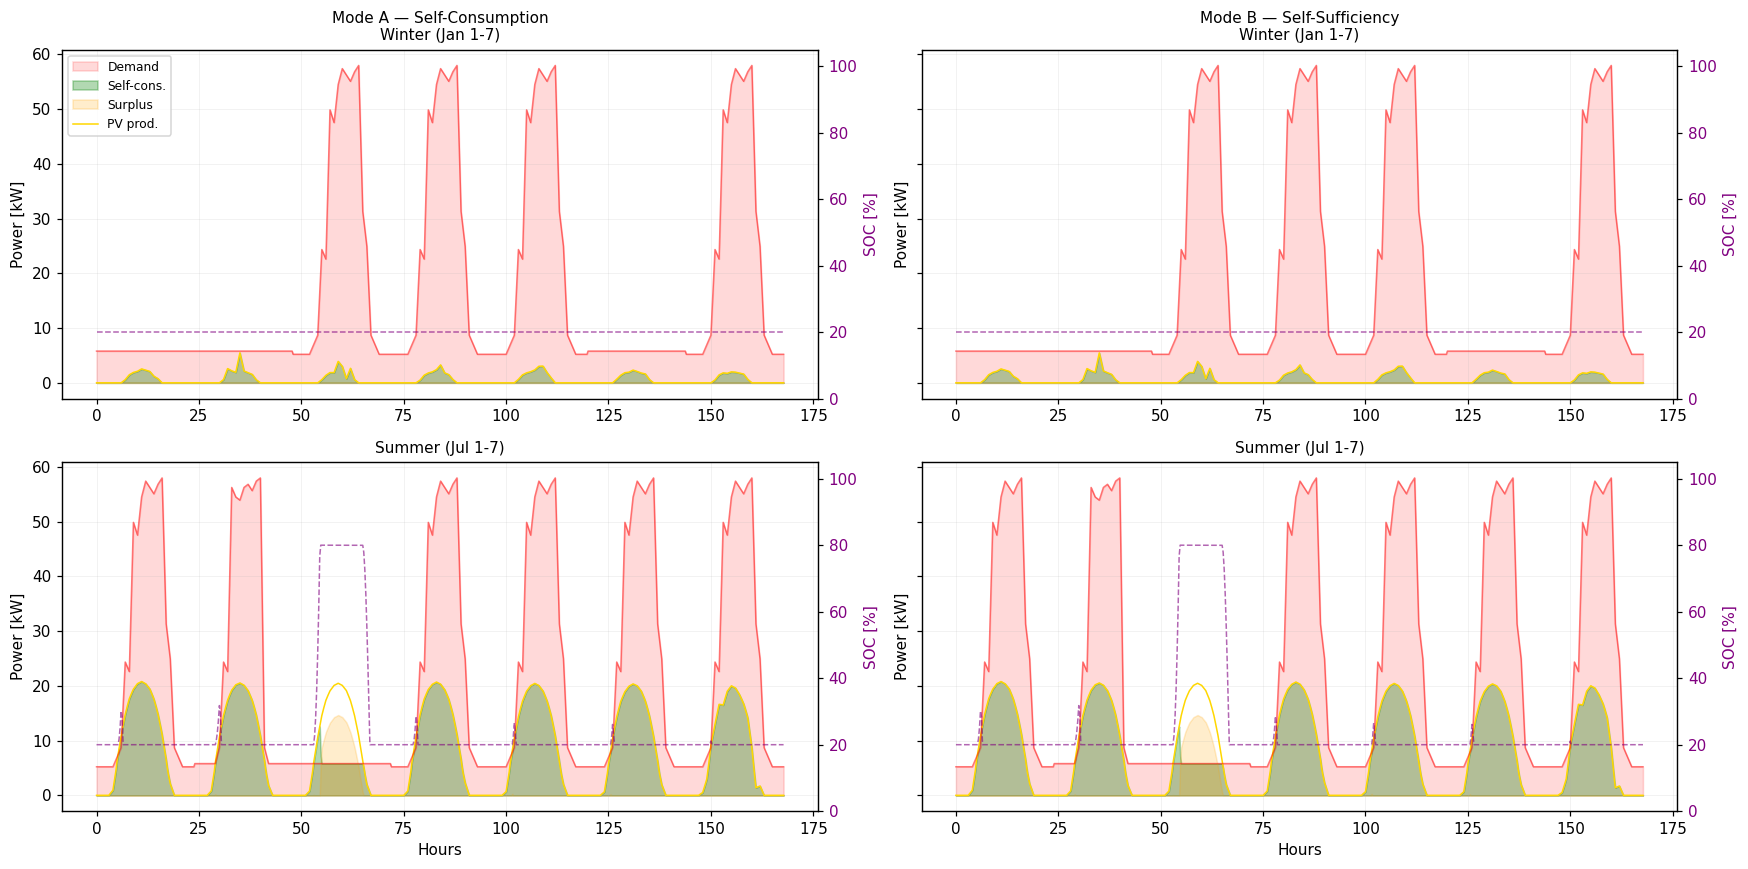

In [15]:
steps_per_day = int(24 / time_step)

seasons = {
    'Winter (Jan 1-7)':  slice(0, 7 * steps_per_day),
    'Summer (Jul 1-7)':  slice(181 * steps_per_day, 188 * steps_per_day),
}

configs = [
    ('Mode A — Self-Consumption', en_a, n_bess_opt, cap_pv_opt, cap_bess_opt),
    ('Mode B — Self-Sufficiency', en_b, n_bess_ss, cap_pv_ss, cap_bess_ss),
]

fig, axes = plt.subplots(len(seasons), len(configs), figsize=(16, 4 * len(seasons)),
                         sharex=False, sharey='row')

for col, (mode_label, en_x, n_b, cap_pv, cap_bess) in enumerate(configs):
    for row, (season_label, sl) in enumerate(seasons.items()):
        ax = axes[row, col]
        hours = np.arange(len(en_x['prod'][sl])) * time_step
        ax.fill_between(hours, en_x['dem'][sl], alpha=0.15, color='red', label='Demand')
        ax.fill_between(hours, en_x['self_cons'][sl], alpha=0.3, color='green', label='Self-cons.')
        ax.fill_between(hours, en_x['surplus'][sl], alpha=0.2, color='orange', label='Surplus')
        ax.plot(hours, en_x['prod'][sl], linewidth=1, color='gold', label='PV prod.')
        ax.plot(hours, en_x['dem'][sl], linewidth=1, color='red', alpha=0.5)
        if n_b > 0:
            ax2 = ax.twinx()
            ax2.plot(hours, en_x['soc'][sl] * 100, linewidth=1, color='purple',
                     alpha=0.6, linestyle='--', label='SOC')
            ax2.set_ylabel('SOC [%]', color='purple')
            ax2.set_ylim(0, 105)
            ax2.tick_params(axis='y', labelcolor='purple')
        ax.set_ylabel('Power [kW]')
        if row == 0:
            ax.set_title(f'{mode_label}\n{season_label}', fontsize=10)
        else:
            ax.set_title(season_label, fontsize=10)
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.2)
        if row == len(seasons) - 1:
            ax.set_xlabel('Hours')

fig.tight_layout()
plt.show()

### Monthly Energy Balance

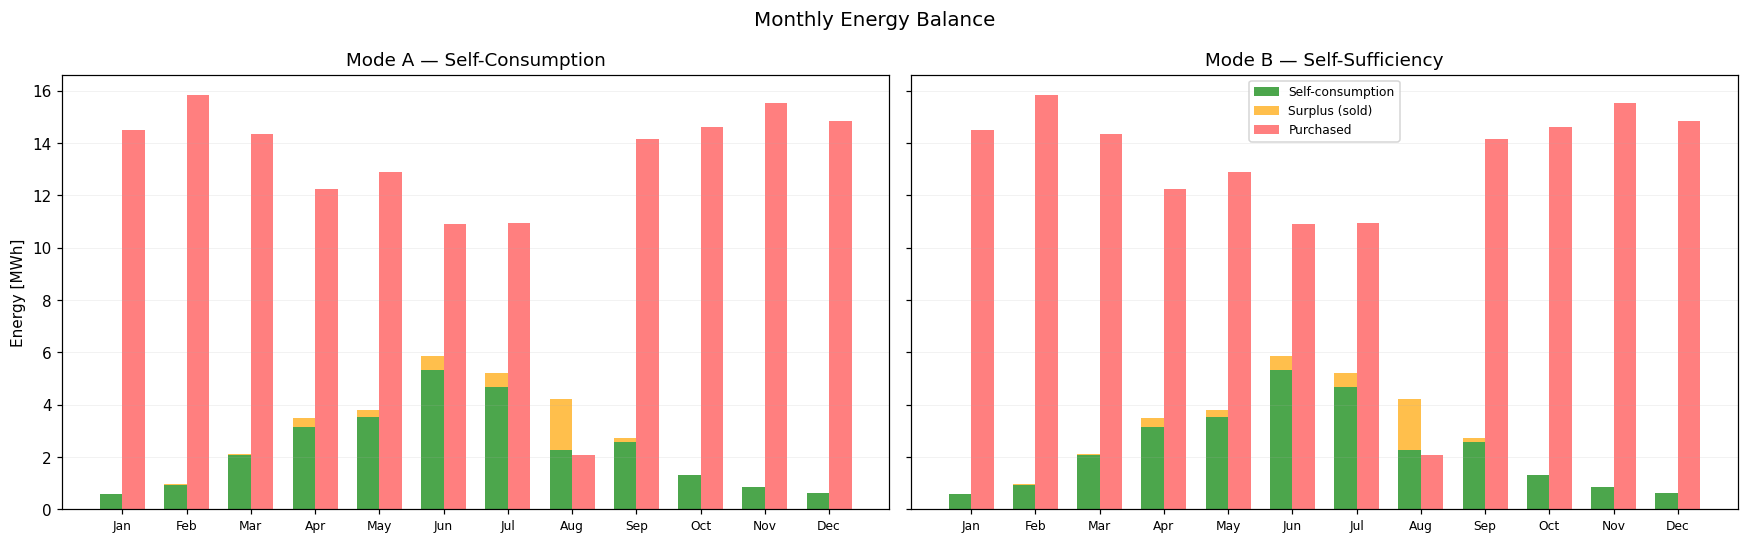

In [16]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(12)
w = 0.35

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, en_x, label in [(ax_a, en_a, 'Mode A — Self-Consumption'),
                         (ax_b, en_b, 'Mode B — Self-Sufficiency')]:
    n_steps = len(en_x['prod'])
    months = np.repeat(np.arange(12), n_steps // 12 + 1)[:n_steps]
    monthly = pd.DataFrame({
        'month': months,
        'prod': en_x['prod'] * time_step / 1000,
        'self_cons': en_x['self_cons'] * time_step / 1000,
        'surplus': en_x['surplus'] * time_step / 1000,
        'purchased': en_x['unmet'] * time_step / 1000,
    }).groupby('month').sum()

    ax.bar(x - w/2, monthly['self_cons'], w, label='Self-consumption', color='green', alpha=0.7)
    ax.bar(x - w/2, monthly['surplus'], w, bottom=monthly['self_cons'],
           label='Surplus (sold)', color='orange', alpha=0.7)
    ax.bar(x + w/2, monthly['purchased'], w, label='Purchased', color='red', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(label)
    ax.grid(True, alpha=0.2, axis='y')

ax_a.set_ylabel('Energy [MWh]')
ax_b.legend(fontsize=8)
fig.suptitle('Monthly Energy Balance', fontsize=13)
fig.tight_layout()
plt.show()

---
## **Step 7 - Economic Performance**

Annual cashflow and cumulative cashflow for both configurations.

In [17]:
ec_a = sim_a['economics']
ec_b = sim_b['economics']
th = opt_sc.time_horizon
years = np.arange(th + 1)

for tag, ec_x in [('Mode A (Self-Consumption)', ec_a), ('Mode B (Self-Sufficiency)', ec_b)]:
    print(f"--- {tag} — Economic Summary ---")
    print(f"  CAPEX:             {ec_x['capex']:>10,.0f} EUR")
    print(f"  NPV (incremental): {ec_x['NPV_incremental']:>10,.0f} EUR")
    print(f"  Payback period:    {ec_x['pbp']:>10.1f} years")
    print()

--- Mode A (Self-Consumption) — Economic Summary ---
  CAPEX:                 55,411 EUR
  NPV (incremental):     24,796 EUR
  Payback period:          -3.8 years

--- Mode B (Self-Sufficiency) — Economic Summary ---
  CAPEX:                 55,411 EUR
  NPV (incremental):     24,796 EUR
  Payback period:          -3.8 years



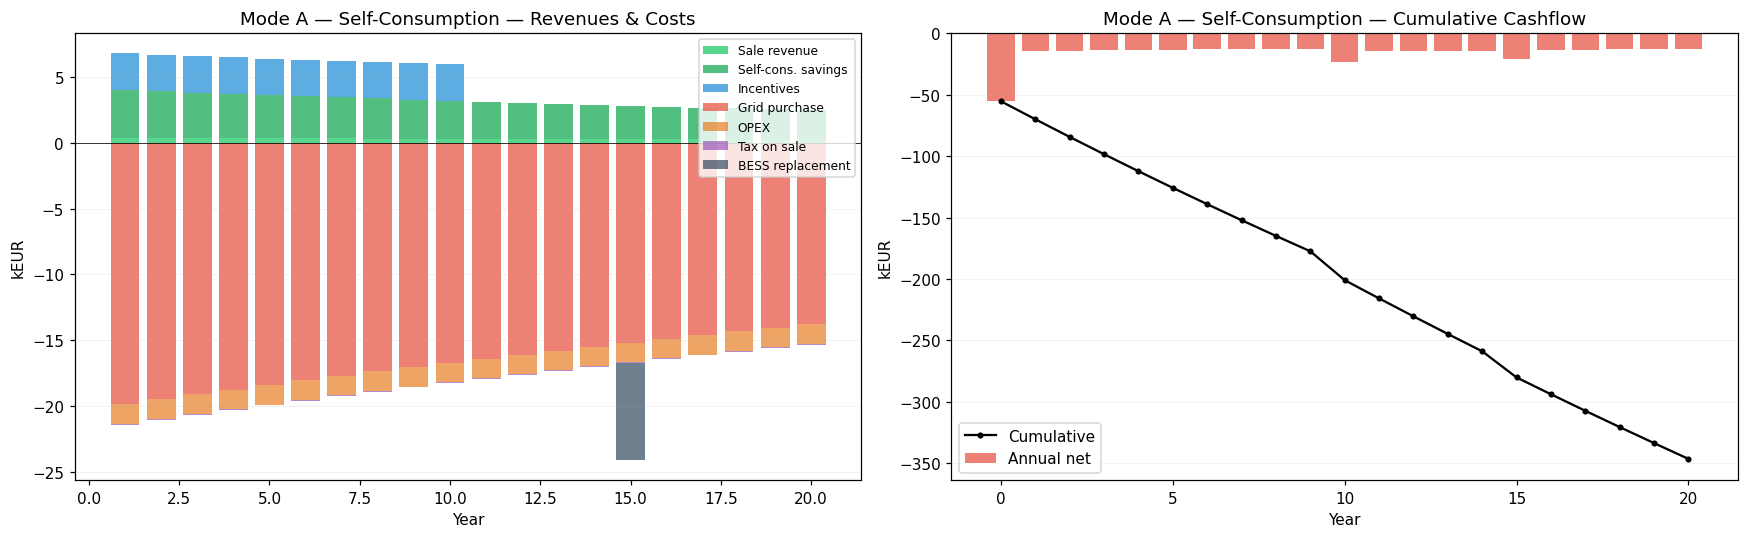

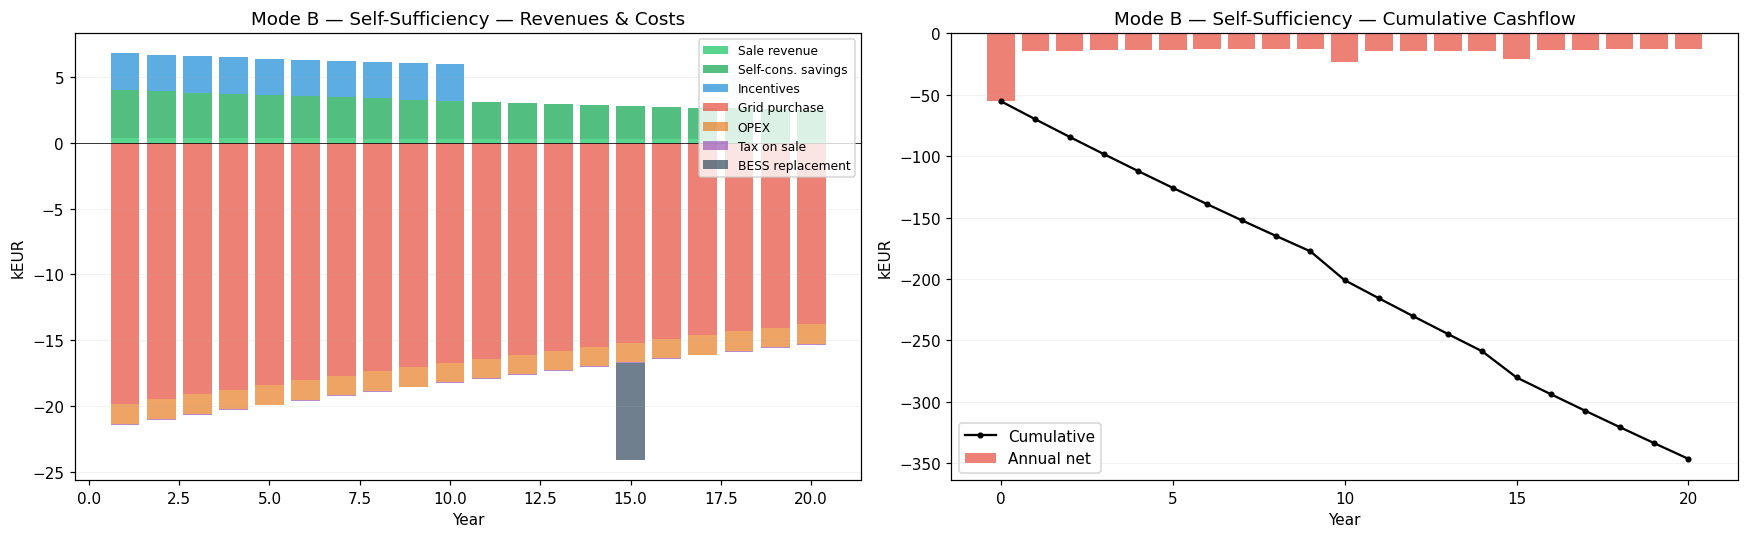

In [18]:
def _plot_cashflow(ec_x, years, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    yr = years[1:]
    r_sale = ec_x['rev_from_sale'][1:]
    r_sav  = ec_x['rev_savings'][1:]
    r_inc  = ec_x['rev_incentives'][1:]
    c_res  = ec_x['cost_resources'][1:]
    c_opex = ec_x['cost_opex'][1:]
    c_tax  = ec_x['cost_taxes_on_sale'][1:]
    c_repl = ec_x['cost_bess_replacement'][1:]

    ax1.bar(yr, r_sale/1000, label='Sale revenue', color='#2ecc71', alpha=0.8)
    ax1.bar(yr, r_sav/1000, bottom=r_sale/1000, label='Self-cons. savings', color='#27ae60', alpha=0.8)
    ax1.bar(yr, r_inc/1000, bottom=(r_sale+r_sav)/1000, label='Incentives', color='#3498db', alpha=0.8)
    ax1.bar(yr, -c_res/1000, label='Grid purchase', color='#e74c3c', alpha=0.7)
    ax1.bar(yr, -c_opex/1000, bottom=-c_res/1000, label='OPEX', color='#e67e22', alpha=0.7)
    ax1.bar(yr, -c_tax/1000, bottom=-(c_res+c_opex)/1000, label='Tax on sale', color='#9b59b6', alpha=0.7)
    if c_repl.sum() > 0:
        ax1.bar(yr, -c_repl/1000, bottom=-(c_res+c_opex+c_tax)/1000,
                label='BESS replacement', color='#34495e', alpha=0.7)
    ax1.axhline(0, color='k', linewidth=0.5)
    ax1.set(xlabel='Year', ylabel='kEUR', title=f'{title} — Revenues & Costs')
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(True, alpha=0.2, axis='y')

    inflow = ec_x['rev_from_sale'] + ec_x['rev_savings'] + ec_x['rev_incentives'] + ec_x['rev_others']
    outflow = (ec_x['cost_resources'] + ec_x['cost_opex'] + ec_x['cost_taxes']
               + ec_x['cost_taxes_on_sale'] + ec_x['cost_others'] + ec_x['cost_bess_replacement'])
    outflow[0] = ec_x['capex']
    net_annual = inflow - outflow
    cumulative = np.cumsum(net_annual)

    ax2.bar(years, net_annual/1000, color=np.where(net_annual >= 0, '#2ecc71', '#e74c3c'),
            alpha=0.7, label='Annual net')
    ax2.plot(years, cumulative/1000, 'k-o', markersize=3, linewidth=1.5, label='Cumulative')
    ax2.axhline(0, color='k', linewidth=0.5)
    ax2.set(xlabel='Year', ylabel='kEUR', title=f'{title} — Cumulative Cashflow')
    ax2.legend()
    ax2.grid(True, alpha=0.2, axis='y')
    fig.tight_layout()
    plt.show()

_plot_cashflow(ec_a, years, 'Mode A — Self-Consumption')
_plot_cashflow(ec_b, years, 'Mode B — Self-Sufficiency')

---
## **Step 8 - Environmental Performance**

CO₂ emissions avoided and fossil fuel savings for both configurations.

In [19]:
CO2_FACTOR = 256  # gCO2/kWh (ISPRA 2023)

GRID_FUEL_MIX = {
    'natural_gas':  {'share': 0.42, 'efficiency': 0.50, 'toe_per_MWh': 0.086},
    'coal':         {'share': 0.04, 'efficiency': 0.38, 'toe_per_MWh': 0.086},
    'oil':          {'share': 0.03, 'efficiency': 0.38, 'toe_per_MWh': 0.086},
}

def _env_perf(ann_x, label):
    displaced = ann_x['self_cons_MWh'] + ann_x['surplus_MWh']
    co2_ton = displaced * 1000 * CO2_FACTOR / 1e6
    fossil = {}
    for fuel, d in GRID_FUEL_MIX.items():
        fossil[fuel] = displaced * d['share'] / d['efficiency'] * d['toe_per_MWh']
    total_toe = sum(fossil.values())
    print(f"--- {label} — Environmental Performance (Year 1) ---")
    print(f"  Displaced electricity:  {displaced:.1f} MWh")
    print(f"  CO2 avoided:            {co2_ton:.2f} tCO2/year")
    print(f"  CO2 avoided (20 years): {co2_ton * 20:.1f} tCO2")
    print(f"  Fossil fuel savings:    {total_toe:.2f} toe/year")
    for fuel, toe in fossil.items():
        print(f"    {fuel:15s}: {toe:.3f} toe")
    print()
    return displaced, co2_ton, total_toe

disp_a, co2_a, toe_a = _env_perf(ann_a, 'Mode A (Self-Consumption)')
disp_b, co2_b, toe_b = _env_perf(ann_b, 'Mode B (Self-Sufficiency)')

--- Mode A (Self-Consumption) — Environmental Performance (Year 1) ---
  Displaced electricity:  31.8 MWh
  CO2 avoided:            8.14 tCO2/year
  CO2 avoided (20 years): 162.9 tCO2
  Fossil fuel savings:    2.80 toe/year
    natural_gas    : 2.298 toe
    coal           : 0.288 toe
    oil            : 0.216 toe

--- Mode B (Self-Sufficiency) — Environmental Performance (Year 1) ---
  Displaced electricity:  31.8 MWh
  CO2 avoided:            8.14 tCO2/year
  CO2 avoided (20 years): 162.9 tCO2
  Fossil fuel savings:    2.80 toe/year
    natural_gas    : 2.298 toe
    coal           : 0.288 toe
    oil            : 0.216 toe



### Summary Tables (per mode)

In [20]:
def _summary(sim_x, ann_x, ec_x, co2, toe, label):
    return {
        'PV capacity [kWp]': f"{sim_x['config']['cap_pv_kW']:.1f}",
        'BESS capacity [kWh]': f"{sim_x['config']['cap_bess_kWh']:.1f}",
        'Annual production [MWh]': f"{ann_x['prod_MWh']:.1f}",
        'Annual demand [MWh]': f"{ann_x['dem_MWh']:.1f}",
        'Self-consumption [MWh]': f"{ann_x['self_cons_MWh']:.1f}",
        'Self-sufficiency rate': f"{ann_x['self_suff_rate']:.1%}",
        'Self-consumption rate': f"{ann_x['self_cons_rate']:.1%}",
        'CAPEX [EUR]': f"{ec_x['capex']:,.0f}",
        'NPV incremental [EUR]': f"{ec_x['NPV_incremental']:,.0f}",
        'Payback [years]': f"{ec_x['pbp']:.1f}",
        'CO\u2082 avoided [tCO\u2082/y]': f"{co2:.2f}",
        'Fossil savings [toe/y]': f"{toe:.2f}",
    }

rows_a = _summary(sim_a, ann_a, ec_a, co2_a, toe_a, 'A')
rows_b = _summary(sim_b, ann_b, ec_b, co2_b, toe_b, 'B')

summary_df = pd.DataFrame({'Mode A (Self-Consumption)': rows_a,
                            'Mode B (Self-Sufficiency)': rows_b})
summary_df.index.name = 'Indicator'
summary_df

,Mode A (Self-Consumption),Mode B (Self-Sufficiency)
Indicator,,
PV capacity [kWp],32.0,32.0
BESS capacity [kWh],10.2,10.2
Annual production [MWh],31.8,31.8
Annual demand [MWh],180.8,180.8
Self-consumption [MWh],28.0,28.0
Self-sufficiency rate,15.4%,15.4%
Self-consumption rate,87.9%,87.9%
CAPEX [EUR],"55,411","55,411"
NPV incremental [EUR],"24,796","24,796"


---
## **Step 9 - Sensitivity: Effect of Budget**

How does the budget constraint affect the Pareto front?

In [21]:
budgets = [1500, 2000, 3000]
sens = {}

for b in budgets:
    kw = {**common_kwargs, 'specific_budget': b, 'objective_mode': 'self_consumption',
          'pop_size': 60, 'n_gen': 50}
    opt_tmp = ProsumerOptimizer(**kw)
    try:
        sens[b] = opt_tmp.optimize()
        n_sol = len(sens[b].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess']))
        n_gen_actual = len(opt_tmp.result.history)
        print(f"Budget {b} EUR/kWp -> {n_sol} solutions (converged in {n_gen_actual} gen)")
    except RuntimeError as e:
        print(f"Budget {b} EUR/kWp -> no feasible solutions ({e})")

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       53 |      1 |  0.000000E+00 |  1.037895E+04 |             - |             -
     2 |       83 |      1 |  0.000000E+00 |  1.742713E+03 |  0.000000E+00 |             f
     3 |      113 |      1 |  0.000000E+00 |  0.0036723423 |  0.000000E+00 |             f
     4 |      143 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      173 |      4 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
     6 |      203 |      8 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |      233 |      6 |  0.000000E+00 |  0.000000E+00 |  0.1524821709 |         ideal
     8 |      263 |      8 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      293 |     21 |  0.000000E+00 |  0.000000E+00 |  0.3307682554 |         ideal
    10 |      323 |     33 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

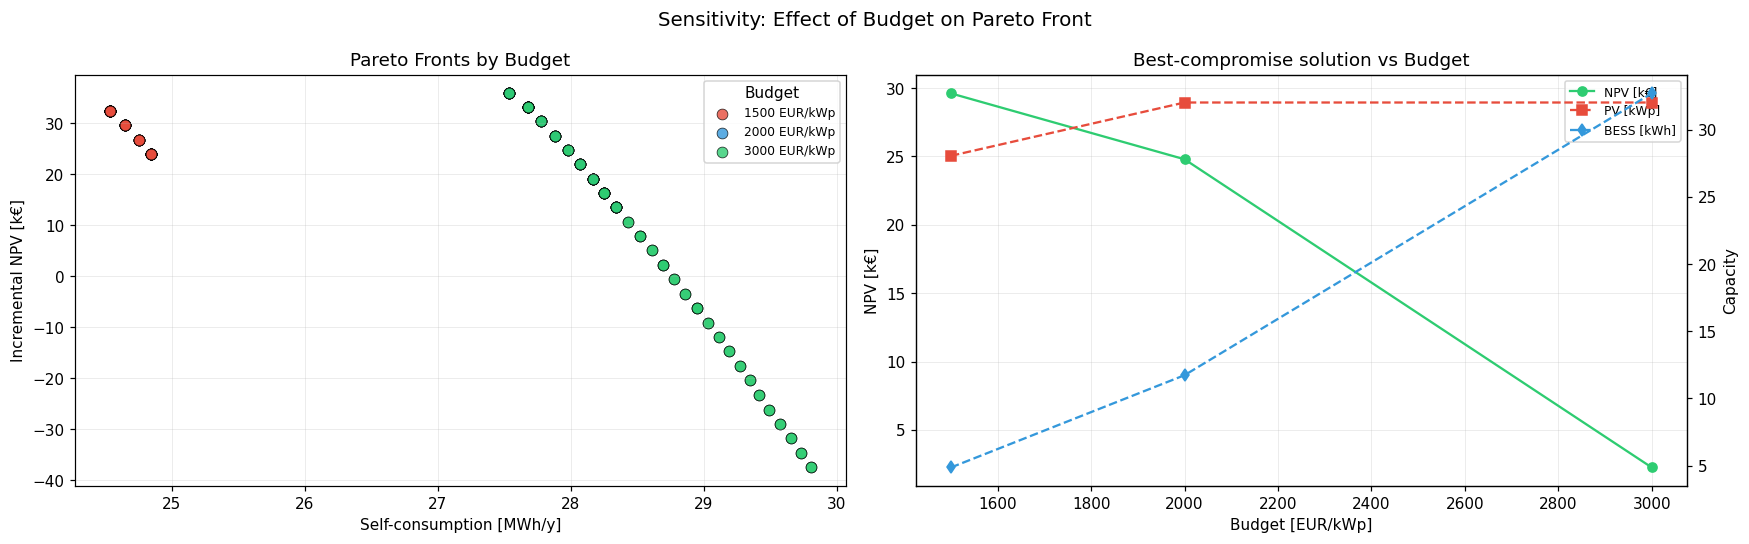

In [22]:
feasible_budgets = [b for b in budgets if b in sens]
colors_bud = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'][:len(feasible_budgets)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Pareto fronts ---
ax = axes[0]
for b, c in zip(feasible_budgets, colors_bud):
    df = sens[b]
    ax.scatter(df['self_cons_MWh'], df['NPV_EUR'] / 1000, s=50, c=c,
               edgecolors='k', linewidths=0.5, alpha=0.8, label=f'{b} EUR/kWp')
ax.set(xlabel='Self-consumption [MWh/y]', ylabel='Incremental NPV [k\u20ac]')
ax.set_title('Pareto Fronts by Budget')
ax.legend(title='Budget', fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: best-compromise KPIs vs budget ---
best_npv_b, best_sc_b, best_pv_b, best_bess_b = [], [], [], []
for b in feasible_budgets:
    df = sens[b].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess'])
    sc_norm = (df['self_cons_MWh'] - df['self_cons_MWh'].min()) / \
              (df['self_cons_MWh'].max() - df['self_cons_MWh'].min() + 1e-9)
    npv_norm = (df['NPV_EUR'] - df['NPV_EUR'].min()) / \
               (df['NPV_EUR'].max() - df['NPV_EUR'].min() + 1e-9)
    dist = np.sqrt((1 - sc_norm)**2 + (1 - npv_norm)**2)
    idx = dist.idxmin()
    best_npv_b.append(df.loc[idx, 'NPV_EUR'] / 1000)
    best_sc_b.append(df.loc[idx, 'self_cons_MWh'])
    best_pv_b.append(df.loc[idx, 'cap_pv_kW'])
    best_bess_b.append(df.loc[idx, 'cap_bess_kWh'])

ax2 = axes[1]
ax2.plot(feasible_budgets, best_npv_b, 'o-', color='#2ecc71', label='NPV [k\u20ac]')
ax2.set(xlabel='Budget [EUR/kWp]', ylabel='NPV [k\u20ac]')
ax2.set_title('Best-compromise solution vs Budget')
ax2.grid(True, alpha=0.3)

ax3 = ax2.twinx()
ax3.plot(feasible_budgets, best_pv_b, 's--', color='#e74c3c', label='PV [kWp]')
ax3.plot(feasible_budgets, best_bess_b, 'd--', color='#3498db', label='BESS [kWh]')
ax3.set_ylabel('Capacity')

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='best', fontsize=8)

fig.suptitle('Sensitivity: Effect of Budget on Pareto Front', fontsize=13)
fig.tight_layout()
plt.show()

---
## **Step 10 - Sensitivity: Effect of Minimum Self-Consumption Ratio**

The `min_self_cons_ratio` constraint forces each solution to consume locally at least a given
fraction of its demand. Sweeping this parameter from **30 %** to **70 %** shows how tighter
self-consumption requirements shift the Pareto front and influence optimal sizing.

In [23]:
sc_ratios = np.arange(0.30, 0.75, 0.10)  # 30%, 40%, 50%, 60%, 70%
sc_ratios = np.round(sc_ratios, 2)
sens_sc = {}

for ratio in sc_ratios:
    kw = {**common_kwargs, 'min_self_cons_ratio': ratio,
          'objective_mode': 'self_consumption',
          'pop_size': 60, 'n_gen': 50}
    opt_tmp = ProsumerOptimizer(**kw)
    try:
        sens_sc[ratio] = opt_tmp.optimize()
        n_sol = len(sens_sc[ratio].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess']))
        n_gen_actual = len(opt_tmp.result.history)
        print(f"min_self_cons_ratio = {ratio:.0%} -> {n_sol} solutions (converged in {n_gen_actual} gen)")
    except RuntimeError as e:
        print(f"min_self_cons_ratio = {ratio:.0%} -> no feasible solutions ({e})")

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       56 |      1 |  0.1442484577 |  6.977634E+03 |             - |             -
     2 |       86 |      1 |  0.1442484577 |  6.384290E+01 |             - |             -
     3 |      116 |      1 |  0.1442484577 |  0.1955964669 |             - |             -
     4 |      146 |      1 |  0.1442484577 |  0.1779193321 |             - |             -
     5 |      176 |      1 |  0.1442484577 |  0.1665534592 |             - |             -
     6 |      206 |      1 |  0.1442484577 |  0.1604588853 |             - |             -
     7 |      236 |      1 |  0.1442484577 |  0.1588358750 |             - |             -
     8 |      266 |      1 |  0.1442484577 |  0.1582465925 |             - |             -
     9 |      296 |      1 |  0.1442484577 |  0.1571829638 |             - |             -
    10 |      326 |      1 |  0.1442484577 |  0.1565833486 |             - |             -

/var/folders/6h/6q8q3hq56bbgv2ppd_2nvc7r0000gn/T/ipykernel_28813/4168589458.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Min SC ratio', fontsize=8)


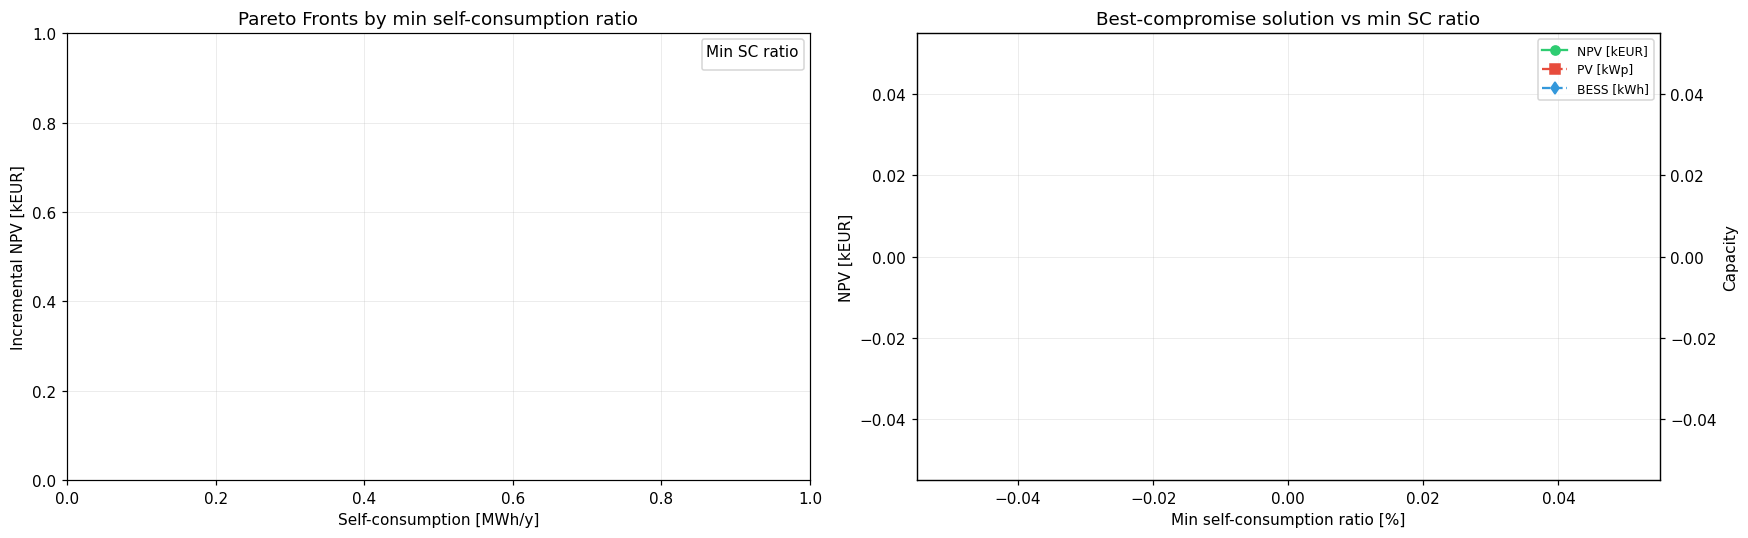

In [24]:
feasible_ratios = np.array([r for r in sc_ratios if r in sens_sc])
cmap = plt.cm.viridis
colors_sc = [cmap(i / max(len(feasible_ratios) - 1, 1)) for i in range(len(feasible_ratios))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Pareto fronts ---
ax = axes[0]
for ratio, c in zip(feasible_ratios, colors_sc):
    df = sens_sc[ratio]
    ax.scatter(df['self_cons_MWh'], df['NPV_EUR'] / 1000,
               s=50, color=c, edgecolors='k', linewidths=0.5,
               alpha=0.8, label=f'{ratio:.0%}')
ax.set(xlabel='Self-consumption [MWh/y]', ylabel='Incremental NPV [kEUR]')
ax.set_title('Pareto Fronts by min self-consumption ratio')
ax.legend(title='Min SC ratio', fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: best-compromise KPIs vs ratio ---
best_npv, best_sc, best_pv, best_bess = [], [], [], []
for ratio in feasible_ratios:
    df = sens_sc[ratio].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess'])
    # best-compromise: closest to utopia (max SC, max NPV)
    sc_norm = (df['self_cons_MWh'] - df['self_cons_MWh'].min()) / \
              (df['self_cons_MWh'].max() - df['self_cons_MWh'].min() + 1e-9)
    npv_norm = (df['NPV_EUR'] - df['NPV_EUR'].min()) / \
               (df['NPV_EUR'].max() - df['NPV_EUR'].min() + 1e-9)
    dist = np.sqrt((1 - sc_norm)**2 + (1 - npv_norm)**2)
    idx = dist.idxmin()
    best_npv.append(df.loc[idx, 'NPV_EUR'] / 1000)
    best_sc.append(df.loc[idx, 'self_cons_MWh'])
    best_pv.append(df.loc[idx, 'cap_pv_kW'])
    best_bess.append(df.loc[idx, 'cap_bess_kWh'])

ax2 = axes[1]
ax2.plot(feasible_ratios * 100, best_npv, 'o-', color='#2ecc71', label='NPV [kEUR]')
ax2.set(xlabel='Min self-consumption ratio [%]', ylabel='NPV [kEUR]')
ax2.set_title('Best-compromise solution vs min SC ratio')
ax2.grid(True, alpha=0.3)

ax3 = ax2.twinx()
ax3.plot(feasible_ratios * 100, best_pv, 's--', color='#e74c3c', label='PV [kWp]')
ax3.plot(feasible_ratios * 100, best_bess, 'd--', color='#3498db', label='BESS [kWh]')
ax3.set_ylabel('Capacity')

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='best', fontsize=8)

fig.tight_layout()
plt.show()

---
## **Step 10b - Sensitivity: Effect of Electricity Price (PUN)**

The `price_buy` parameter (grid import price) directly affects the economic attractiveness of
self-consumption. Higher PUN makes self-produced energy more valuable, shifting the Pareto
front towards higher NPV. We sweep from **-40%** to **+60%** around the baseline
(130 EUR/MWh).

In [ ]:
pun_base = common_kwargs['prosumer_economics']['price_buy']  # 130 EUR/MWh
pun_deltas = np.arange(-0.40, 0.65, 0.10)  # -40% to +60%
pun_deltas = np.round(pun_deltas, 2)
sens_pun = {}

for delta in pun_deltas:
    price_buy_new = pun_base * (1 + delta)
    pe_new = {**common_kwargs['prosumer_economics'], 'price_buy': price_buy_new}
    kw = {**common_kwargs, 'prosumer_economics': pe_new,
          'objective_mode': 'self_consumption',
          'pop_size': 60, 'n_gen': 50}
    opt_tmp = ProsumerOptimizer(**kw)
    try:
        sens_pun[delta] = opt_tmp.optimize()
        n_sol = len(sens_pun[delta].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess']))
        n_gen_actual = len(opt_tmp.result.history)
        print(f"PUN {delta:+.0%} ({price_buy_new:.0f} EUR/MWh) -> {n_sol} solutions (converged in {n_gen_actual} gen)")
    except RuntimeError as e:
        print(f"PUN {delta:+.0%} ({price_buy_new:.0f} EUR/MWh) -> no feasible solutions ({e})")

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       56 |      6 |  0.000000E+00 |  6.977435E+03 |             - |             -
     2 |       86 |      8 |  0.000000E+00 |  1.6897041149 |  0.0527158039 |             f
     3 |      116 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0053775706 |         ideal
     4 |      146 |     16 |  0.000000E+00 |  0.000000E+00 |  0.0174121464 |             f
     5 |      176 |     18 |  0.000000E+00 |  0.000000E+00 |  0.0103120249 |             f
     6 |      206 |     28 |  0.000000E+00 |  0.000000E+00 |  0.0149331548 |             f
     7 |      236 |     12 |  0.000000E+00 |  0.000000E+00 |  0.0153575250 |             f
     8 |      266 |     21 |  0.000000E+00 |  0.000000E+00 |  0.6665957223 |         nadir
     9 |      296 |     31 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
    10 |      326 |     43 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

In [ ]:
feasible_deltas = np.array([d for d in pun_deltas if d in sens_pun])
cmap_pun = plt.cm.coolwarm
colors_pun = [cmap_pun((d - feasible_deltas.min()) / (feasible_deltas.max() - feasible_deltas.min() + 1e-9))
              for d in feasible_deltas]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Pareto fronts ---
ax = axes[0]
for delta, c in zip(feasible_deltas, colors_pun):
    df = sens_pun[delta]
    price_label = pun_base * (1 + delta)
    ax.scatter(df['self_cons_MWh'], df['NPV_EUR'] / 1000, s=45, color=c,
               edgecolors='k', linewidths=0.4, alpha=0.8,
               label=f'{delta:+.0%} ({price_label:.0f} \u20ac/MWh)')
ax.set(xlabel='Self-consumption [MWh/y]', ylabel='Incremental NPV [k\u20ac]')
ax.set_title('Pareto Fronts by PUN')
ax.legend(title='PUN variation', fontsize=7, loc='best')
ax.grid(True, alpha=0.3)

# --- Right: best-compromise KPIs vs PUN ---
best_npv_p, best_sc_p, best_pv_p, best_bess_p = [], [], [], []
for delta in feasible_deltas:
    df = sens_pun[delta].drop_duplicates(subset=['n_parallel_pv', 'n_parallel_bess'])
    sc_norm = (df['self_cons_MWh'] - df['self_cons_MWh'].min()) / \
              (df['self_cons_MWh'].max() - df['self_cons_MWh'].min() + 1e-9)
    npv_norm = (df['NPV_EUR'] - df['NPV_EUR'].min()) / \
               (df['NPV_EUR'].max() - df['NPV_EUR'].min() + 1e-9)
    dist = np.sqrt((1 - sc_norm)**2 + (1 - npv_norm)**2)
    idx = dist.idxmin()
    best_npv_p.append(df.loc[idx, 'NPV_EUR'] / 1000)
    best_sc_p.append(df.loc[idx, 'self_cons_MWh'])
    best_pv_p.append(df.loc[idx, 'cap_pv_kW'])
    best_bess_p.append(df.loc[idx, 'cap_bess_kWh'])

pun_prices = feasible_deltas * pun_base + pun_base

ax2 = axes[1]
ax2.plot(pun_prices, best_npv_p, 'o-', color='#2ecc71', label='NPV [k\u20ac]')
ax2.set(xlabel='PUN [EUR/MWh]', ylabel='NPV [k\u20ac]')
ax2.set_title('Best-compromise solution vs PUN')
ax2.grid(True, alpha=0.3)

ax3 = ax2.twinx()
ax3.plot(pun_prices, best_pv_p, 's--', color='#e74c3c', label='PV [kWp]')
ax3.plot(pun_prices, best_bess_p, 'd--', color='#3498db', label='BESS [kWh]')
ax3.set_ylabel('Capacity')

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='best', fontsize=8)

fig.suptitle('Sensitivity: Effect of Electricity Price (PUN) on Pareto Front', fontsize=13)
fig.tight_layout()
plt.show()

---
## **Step 11 - Comparative Summary: Mode A vs Mode B**

Side-by-side comparison of the best-compromise solutions from Mode A (Self-Consumption)
and Mode B (Self-Sufficiency), covering energy, economic, and environmental indicators.

In [ ]:
# All variables (sim_a/b, ann_a/b, ec_a/b, disp_a/b, co2_a/b, toe_a/b)
# are already computed above — build the final comparison table.

rows = {
    'PV capacity [kWp]':           (f"{sim_a['config']['cap_pv_kW']:.1f}",
                                    f"{sim_b['config']['cap_pv_kW']:.1f}"),
    'BESS capacity [kWh]':         (f"{sim_a['config']['cap_bess_kWh']:.1f}",
                                    f"{sim_b['config']['cap_bess_kWh']:.1f}"),
    'Annual production [MWh]':     (f"{ann_a['prod_MWh']:.1f}",
                                    f"{ann_b['prod_MWh']:.1f}"),
    'Annual demand [MWh]':         (f"{ann_a['dem_MWh']:.1f}",
                                    f"{ann_b['dem_MWh']:.1f}"),
    'Self-consumption [MWh]':      (f"{ann_a['self_cons_MWh']:.1f}",
                                    f"{ann_b['self_cons_MWh']:.1f}"),
    'Surplus sold [MWh]':          (f"{ann_a['surplus_MWh']:.1f}",
                                    f"{ann_b['surplus_MWh']:.1f}"),
    'Purchased from grid [MWh]':   (f"{ann_a['purchased_MWh']:.1f}",
                                    f"{ann_b['purchased_MWh']:.1f}"),
    'Self-sufficiency rate':       (f"{ann_a['self_suff_rate']:.1%}",
                                    f"{ann_b['self_suff_rate']:.1%}"),
    'Self-consumption rate':       (f"{ann_a['self_cons_rate']:.1%}",
                                    f"{ann_b['self_cons_rate']:.1%}"),
    'CAPEX [EUR]':                 (f"{ec_a['capex']:,.0f}",
                                    f"{ec_b['capex']:,.0f}"),
    'NPV incremental [EUR]':       (f"{ec_a['NPV_incremental']:,.0f}",
                                    f"{ec_b['NPV_incremental']:,.0f}"),
    'Payback period [years]':      (f"{ec_a['pbp']:.1f}",
                                    f"{ec_b['pbp']:.1f}"),
    'Displaced electricity [MWh]': (f"{disp_a:.1f}",
                                    f"{disp_b:.1f}"),
    'CO\u2082 avoided [tCO\u2082/y]':       (f"{co2_a:.2f}",
                                    f"{co2_b:.2f}"),
    'Fossil savings [toe/y]':      (f"{toe_a:.2f}",
                                    f"{toe_b:.2f}"),
}

comp_df = pd.DataFrame(rows, index=['Mode A (Self-Consumption)',
                                     'Mode B (Self-Sufficiency)']).T
comp_df.index.name = 'Indicator'
comp_df

---
## **Summary**

| Parameter | Effect |
|-----------|--------|
| `space_max`, `utilization_factor` | Max PV size |
| `specific_budget` | Total CAPEX constraint |
| `min_self_cons_ratio` | Min local energy use |
| `price_buy` (PUN) | Grid price — higher PUN increases self-consumption value and NPV |
| `pv_economics['cap_cost']` | PV market price |
| `bess_economics['cap_cost']` | Battery cost |
| `n_gen`, `pop_size` | Max computation time (early stopping reduces actual generations) |